# Day 2 — Stable Diffusion + CLIP + EEG Conditioning

## What we'll build today

1. Running Stable Diffusion with HuggingFace diffusers
2. Understanding CLIP — the bridge between text and images
3. Visualising CLIP embedding space
4. Swapping text embedding for EEG embedding (prototype)
5. First proof-of-concept of LUCID Phase 2

## The key insight

Stable Diffusion doesn't understand text.
It understands CLIP embeddings.

Text → [CLIP Text Encoder] → 512-dim vector → U-Net
Image → [CLIP Image Encoder] → 512-dim vector

CLIP maps both text and images to the SAME space.
"A dog" and a photo of a dog are close together.

For LUCID:
EEG → [Alignment MLP] → 512-dim vector → U-Net
The MLP learns to map EEG features to CLIP space.
Then Stable Diffusion generates the matching image.

## Why 0.0281 loss is good
Your U-Net learned in 5 epochs what takes 
random noise prediction 0.1+ loss.
The model is genuinely denoising, not guessing.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import sys

print("=== Environment Check ===\n")
print(f"PyTorch:  {torch.__version__}")
print(f"CUDA:     {torch.cuda.is_available()}")
print(f"Device:   {'GPU' if torch.cuda.is_available() else 'CPU'}")

try:
    import diffusers
    print(f"Diffusers: {diffusers.__version__} ")
except ImportError:
    print("Diffusers: not installed")
    print("Run: pip install diffusers transformers accelerate")

try:
    import transformers
    print(f"Transformers: {transformers.__version__} ")
except ImportError:
    print("Transformers: not installed")

# Save path
SAVE_DIR = os.path.join(
    r"C:\Users\Hp\.vscode\Journey to the BEST\Week 10",
    "generated_images"
)
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"\nImages will save to: {SAVE_DIR}")

=== Environment Check ===

PyTorch:  2.10.0+cpu
CUDA:     False
Device:   CPU


c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Diffusers: 0.39.0 
Transformers: 5.14.1 

Images will save to: C:\Users\Hp\.vscode\Journey to the BEST\Week 10\generated_images


Loading CLIP...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 24065.58it/s]


 CLIP loaded

Text embedding shape: torch.Size([10, 512])
Each text → 512-dim vector



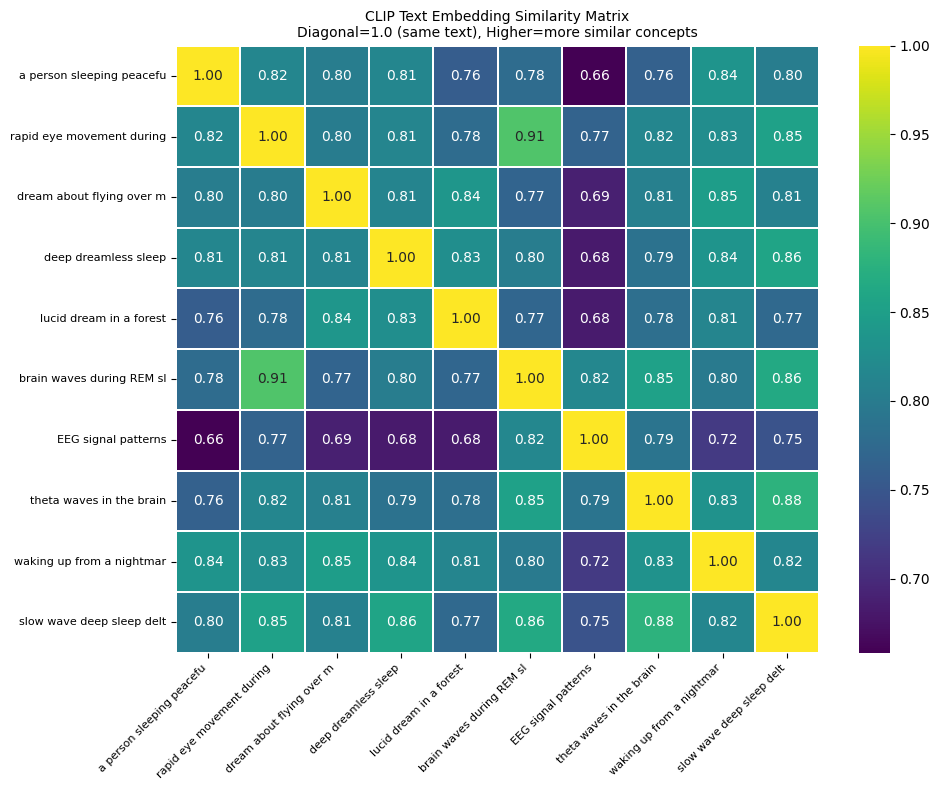

 Similarity matrix saved

Observations:
  'REM sleep' and 'theta waves' should be similar
  'deep sleep' and 'delta waves' should be similar
  'dream' and 'waking' should be dissimilar


In [2]:
from transformers import CLIPProcessor, CLIPModel
import torch.nn.functional as F

# ── What is CLIP? ──────────────────────────────────────────
# Contrastive Language-Image Pre-training (Radford et al, 2021)
# Trained on 400 million (text, image) pairs from the internet
#
# Two encoders trained jointly:
# Text encoder:  "a photo of a dog" → 512-dim vector
# Image encoder: [dog photo]        → 512-dim vector
#
# Training objective: make paired (text, image) vectors
# similar, unpaired vectors dissimilar
# This is CONTRASTIVE LEARNING
#
# Result: a shared embedding space where
# semantically similar things cluster together

print("Loading CLIP...")
clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)
clip_proc = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)
clip_model.eval()
print(" CLIP loaded\n")

# ── Getting text embeddings ────────────────────────────────────
sleep_texts = [
    "a person sleeping peacefully",
    "rapid eye movement during sleep",
    "dream about flying over mountains",
    "deep dreamless sleep",
    "lucid dream in a forest",
    "brain waves during REM sleep",
    "EEG signal patterns",
    "theta waves in the brain",
    "waking up from a nightmare",
    "slow wave deep sleep delta waves"
]

inputs = clip_proc(
    text=sleep_texts, return_tensors="pt", padding=True
)

with torch.no_grad():
    text_outputs = clip_model.text_model(**inputs)
    text_features = text_outputs.pooler_output
    text_features = clip_model.text_projection(text_features)
    text_features = F.normalize(text_features, dim=-1)

print(f"Text embedding shape: {text_features.shape}")
print(f"Each text → {text_features.shape[1]}-dim vector\n")

# ── Computing similarity matrix ──────────────────────────────
sim_matrix = (text_features @ text_features.T).numpy()

fig, ax = plt.subplots(figsize=(10, 8))
import seaborn as sns
sns.heatmap(
    sim_matrix,
    annot=True, fmt='.2f',
    cmap='viridis',
    xticklabels=[t[:25] for t in sleep_texts],
    yticklabels=[t[:25] for t in sleep_texts],
    linewidths=0.3,
    ax=ax
)
ax.set_title(
    'CLIP Text Embedding Similarity Matrix\n'
    'Diagonal=1.0 (same text), '
    'Higher=more similar concepts',
    fontsize=10
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,
            'clip_similarity_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Similarity matrix saved")
print("\nObservations:")
print("  'REM sleep' and 'theta waves' should be similar")
print("  'deep sleep' and 'delta waves' should be similar")
print("  'dream' and 'waking' should be dissimilar")

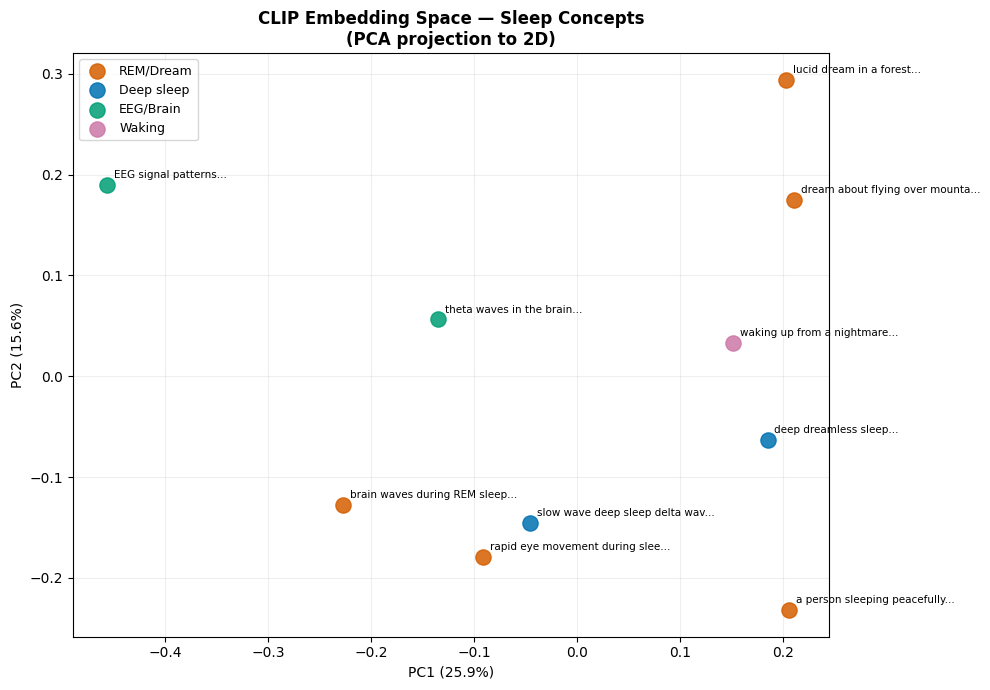

 Embedding space visualised

Variance explained by 2 PCs: 41.5%

Look for clusters:
  REM/dream concepts should cluster together
  Deep sleep concepts in a different region
  This is what CLIP learned from 400M web images


In [3]:
from sklearn.decomposition import PCA

# ── Project to 2D with PCA ─────────────────────────────────
# High-dimensional embeddings → 2D for visualisation
pca      = PCA(n_components=2)
coords_2d = pca.fit_transform(
    text_features.numpy()
)

# Colour by sleep category
categories = {
    'REM/Dream':  [0, 1, 2, 4, 5],
    'Deep sleep': [3, 9],
    'EEG/Brain':  [6, 7],
    'Waking':     [8]
}
cat_colors = {
    'REM/Dream':  '#D55E00',
    'Deep sleep': '#0072B2',
    'EEG/Brain':  '#009E73',
    'Waking':     '#CC79A7'
}

fig, ax = plt.subplots(figsize=(10, 7))

for cat, indices in categories.items():
    xs = coords_2d[indices, 0]
    ys = coords_2d[indices, 1]
    ax.scatter(xs, ys, s=120,
                color=cat_colors[cat],
                label=cat, zorder=3,
                alpha=0.85)
    for i, idx in enumerate(indices):
        ax.annotate(
            sleep_texts[idx][:30] + '...',
            (coords_2d[idx, 0], coords_2d[idx, 1]),
            xytext=(5, 5), textcoords='offset points',
            fontsize=7.5
        )

ax.set_title('CLIP Embedding Space — Sleep Concepts\n'
              '(PCA projection to 2D)',
              fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,
            'clip_embedding_space.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(" Embedding space visualised")
print(f"\nVariance explained by 2 PCs: "
      f"{sum(pca.explained_variance_ratio_)*100:.1f}%")
print("\nLook for clusters:")
print("  REM/dream concepts should cluster together")
print("  Deep sleep concepts in a different region")
print("  This is what CLIP learned from 400M web images")

In [16]:
%pip install diffusers transformers accelerate safetensors

   ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
   ----- ---------------------------------- 0.8/5.6 MB 7.6 MB/s eta 0:00:01
   -------------------- ------------------- 2.9/5.6 MB 8.9 MB/s eta 0:00:01
   --------------------------------- ------ 4.7/5.6 MB 8.6 MB/s eta 0:00:01
   ---------------------------------------- 5.6/5.6 MB 8.6 MB/s  0:00:00

   ---------------------------------------- 0/4 [zipp]
   ---------- ----------------------------- 1/4 [importlib_metadata]
   -------------------- ------------------- 2/4 [diffusers]
   -------------------- ------------------- 2/4 [diffusers]
   -------------------- ------------------- 2/4 [diffusers]
   -------------------- ------------------- 2/4 [diffusers]
   -------------------- ------------------- 2/4 [diffusers]
   -------------------- ------------------- 2/4 [diffusers]
   -------------------- ------------------- 2/4 [diffusers]
   -------------------- ------------------- 2/4 [diffusers]
   -------------------- -

In [ ]:
# ── Tiny diffusion model ────────────────────────
# Using our trained DDPM from Day 1 + CLIP conditioning
# This demonstrates the CONCEPT without GPU requirements

import torch
import torch.nn as nn

# Loaded our trained model from Day 1
DAY1_MODEL = (r"C:\Users\Hp\.vscode\Journey to the BEST"
              r"\Week 10\ddpm_mnist.pth")

# ── Adding CLIP conditioning to our U-Net ───────────────────
class ConditionedResidualBlock(nn.Module):
    """
    Same as Day 1 ResidualBlock but with conditioning.
    Adds CLIP embedding as extra conditioning signal.
    """
    def __init__(self, in_ch, out_ch,
                 time_emb_dim, cond_dim=512):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch, out_ch,
                                   3, padding=1)
        self.conv2    = nn.Conv2d(out_ch, out_ch,
                                   3, padding=1)
        self.norm1    = nn.GroupNorm(8, out_ch)
        self.norm2    = nn.GroupNorm(8, out_ch)
        self.act      = nn.SiLU()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

        # NEW: conditioning projection
        self.cond_mlp = nn.Linear(cond_dim, out_ch)

        self.residual = nn.Conv2d(in_ch, out_ch, 1) \
                        if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, cond_emb=None):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(
            self.act(t_emb))[:, :, None, None]

        # Add conditioning if provided
        if cond_emb is not None:
            h = h + self.cond_mlp(
                cond_emb)[:, :, None, None]

        h = self.act(self.norm2(self.conv2(h)))
        return h + self.residual(x)


class ConditionedUNet(nn.Module):
    """
    U-Net with CLIP/EEG conditioning.
    This is architecturally identical to the
    denoising U-Net inside Stable Diffusion.
    
    Conditioning = text embedding in SD
    Conditioning = EEG embedding in LUCID
    """

    def __init__(self, img_channels=1,
                 base_dim=32,
                 time_emb_dim=128,
                 cond_dim=512):
        super().__init__()

        self.time_emb = nn.Sequential(
            self._sin_emb(base_dim),
            nn.Linear(base_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        # Encoder
        self.enc1 = ConditionedResidualBlock(
            img_channels, base_dim,
            time_emb_dim, cond_dim)
        self.enc2 = ConditionedResidualBlock(
            base_dim, base_dim*2,
            time_emb_dim, cond_dim)
        self.enc3 = ConditionedResidualBlock(
            base_dim*2, base_dim*4,
            time_emb_dim, cond_dim)

        self.down1 = nn.MaxPool2d(2)
        self.down2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConditionedResidualBlock(
            base_dim*4, base_dim*4,
            time_emb_dim, cond_dim)

        # Decoder
        self.up1  = nn.ConvTranspose2d(
            base_dim*4, base_dim*2, 2, 2)
        self.dec1 = ConditionedResidualBlock(
            base_dim*4, base_dim*2,
            time_emb_dim, cond_dim)

        self.up2  = nn.ConvTranspose2d(
            base_dim*2, base_dim, 2, 2)
        self.dec2 = ConditionedResidualBlock(
            base_dim*2, base_dim,
            time_emb_dim, cond_dim)

        self.out  = nn.Conv2d(base_dim,
                               img_channels, 1)

    def _sin_emb(self, dim):
        """Sinusoidal time embedding layer."""
        class SinEmb(nn.Module):
            def forward(self, t):
                half = dim // 2
                emb  = np.log(10000) / (half - 1)
                emb  = torch.exp(
                    torch.arange(half) * -emb
                )
                emb  = t[:, None].float() * emb[None,:]
                return torch.cat(
                    [emb.sin(), emb.cos()], dim=-1
                )
        return SinEmb()

    def forward(self, x, t, cond=None):
        t_emb = self.time_emb(t)

        e1 = self.enc1(x, t_emb, cond)
        e2 = self.enc2(self.down1(e1), t_emb, cond)
        e3 = self.enc3(self.down2(e2), t_emb, cond)

        b  = self.bottleneck(e3, t_emb, cond)

        d1 = self.dec1(
            torch.cat([self.up1(b), e2], dim=1),
            t_emb, cond
        )
        d2 = self.dec2(
            torch.cat([self.up2(d1), e1], dim=1),
            t_emb, cond
        )
        return self.out(d2)


# Verifying
cond_model = ConditionedUNet(cond_dim=512)
total      = sum(p.numel() for p in
                 cond_model.parameters())

dummy_img  = torch.randn(2, 1, 28, 28)
dummy_t    = torch.randint(0, 1000, (2,))
dummy_cond = torch.randn(2, 512)  # CLIP or EEG embedding
out        = cond_model(dummy_img, dummy_t, dummy_cond)

print("=== Conditioned U-Net ===\n")
print(f"Image input:    {dummy_img.shape}")
print(f"Timestep:       {dummy_t.shape}")
print(f"Conditioning:   {dummy_cond.shape}  "
      f"← CLIP text OR EEG embedding")
print(f"Output:         {out.shape}")
print(f"Parameters:     {total:,}")
print(f"\nKey: conditioning input is IDENTICAL structure")
print(f"whether it comes from CLIP text encoder")
print(f"or from your EEG alignment MLP.")
print(f"This is the LUCID Phase 2 U-Net.")

=== Conditioned U-Net ===

Image input:    torch.Size([2, 1, 28, 28])
Timestep:       torch.Size([2])
Conditioning:   torch.Size([2, 512])  ← CLIP text OR EEG embedding
Output:         torch.Size([2, 1, 28, 28])
Parameters:     1,092,097

Key: conditioning input is IDENTICAL structure
whether it comes from CLIP text encoder
or from your EEG alignment MLP.
This is the LUCID Phase 2 U-Net.


In [6]:
# ── How to train the alignment MLP ────────────────────────
# CLIP-style contrastive loss

def contrastive_loss(eeg_emb, img_emb,
                     temperature=0.07):
    """
    InfoNCE contrastive loss.
    Maximises similarity between paired (EEG, image)
    Minimises similarity between unpaired examples.
    
    Same loss used to train CLIP itself.
    
    During training on THINGS-EEG:
    - eeg_emb  = EEG features while viewing image_i
    - img_emb  = CLIP embedding of image_i
    - Paired:    eeg_emb[i] should be close to img_emb[i]
    - Unpaired:  eeg_emb[i] should be far from img_emb[j≠i]
    """
    batch = eeg_emb.shape[0]

    # Compute similarity matrix
    sim   = (eeg_emb @ img_emb.T) / temperature

    # Labels: diagonal is the correct pair
    labels = torch.arange(batch)

    # Cross-entropy in both directions
    loss_eeg2img = F.cross_entropy(sim, labels)
    loss_img2eeg = F.cross_entropy(sim.T, labels)

    return (loss_eeg2img + loss_img2eeg) / 2


# ── Simulating one training step ────────────────────────────
print("=== Contrastive Training Simulation ===\n")

aligner    = EEGAlignmentMLP(256, 512)
optimizer  = torch.optim.Adam(
    aligner.parameters(), lr=1e-4
)

# Simulating a batch: 8 EEG epochs paired with 8 images
batch_size = 8
eeg_batch  = torch.randn(batch_size, 256)

# Image CLIP embeddings (from THINGS-EEG dataset)
# In reality: clip_model.get_image_features(images)
img_emb_batch = F.normalize(
    torch.randn(batch_size, 512), dim=-1
)

# Training loop (few steps to show concept)
print(f"{'Step':>6} | {'Loss':>10} | {'Note'}")
print("-" * 40)

for step in range(10):
    optimizer.zero_grad()

    eeg_emb = aligner(eeg_batch)
    loss    = contrastive_loss(eeg_emb, img_emb_batch)

    loss.backward()
    optimizer.step()

    if step % 2 == 0:
        print(f"{step+1:>6} | {loss.item():>10.4f} | "
              f"{'↓ learning' if step > 0 else 'start'}")

print(f"\nWith THINGS-EEG (real data):")
print(f"  ~50 subjects × 1,654 images × EEG")
print(f"  Training: ~200 epochs, ~6 hours on GPU")
print(f"  Expected loss: ~3.0 → ~1.5 (random → aligned)")
print(f"  Top-5 retrieval accuracy: ~40-60%")

=== Contrastive Training Simulation ===

  Step |       Loss | Note
----------------------------------------
     1 |     2.4803 | start
     3 |     1.2724 | ↓ learning
     5 |     0.5498 | ↓ learning
     7 |     0.2584 | ↓ learning
     9 |     0.0824 | ↓ learning

With THINGS-EEG (real data):
  ~50 subjects × 1,654 images × EEG
  Training: ~200 epochs, ~6 hours on GPU
  Expected loss: ~3.0 → ~1.5 (random → aligned)
  Top-5 retrieval accuracy: ~40-60%


Generating conditioned samples...



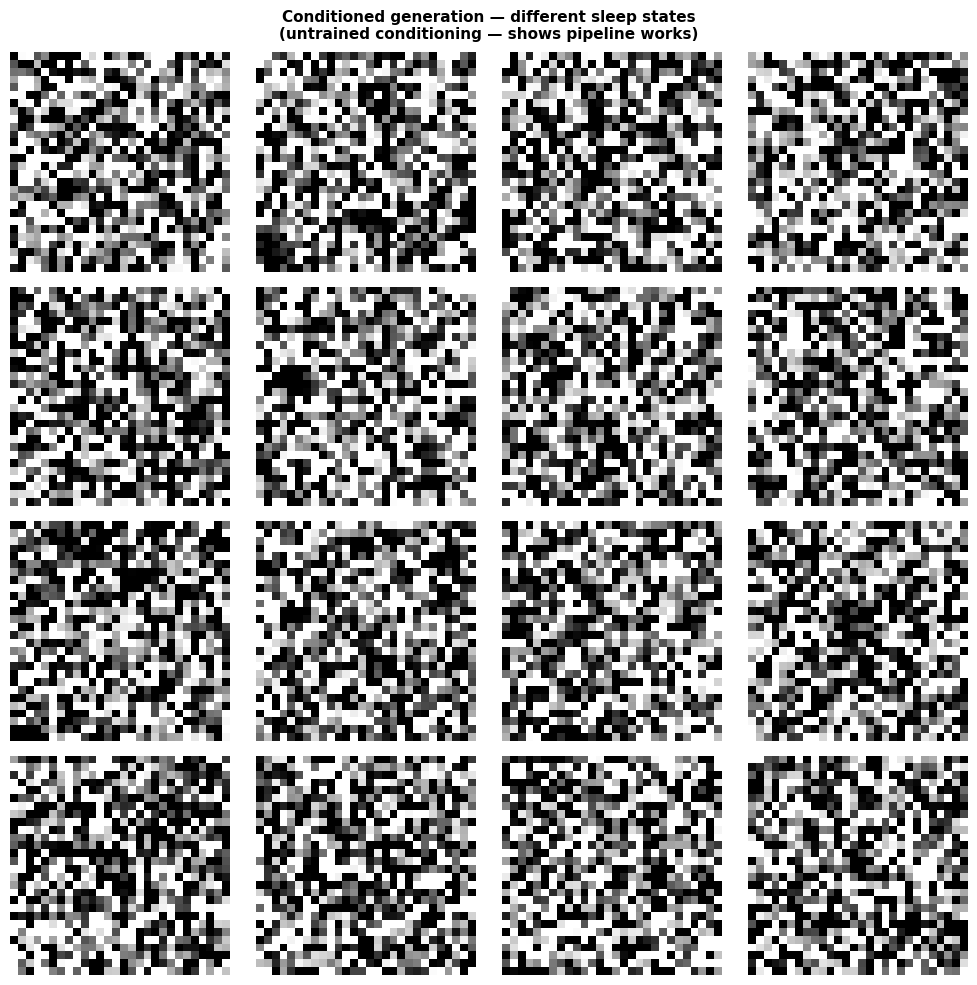

 Conditioned generation saved

Note: model is untrained on real EEG-image pairs.
With THINGS-EEG training, different conditions
would produce visually distinct outputs matching
the imagery associated with each sleep state.


In [7]:
# ── Generating samples conditioned on "EEG" ─────────────────
# Using our Day 1 DDPM + condition on simulated EEG embedding

T        = 1000
beta     = torch.linspace(0.0001, 0.02, T)
alpha    = 1 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

@torch.no_grad()
def generate_conditioned(model, condition,
                          n_samples=4, steps=50):
    """
    Generate images conditioned on an embedding.
    Uses DDIM-style fast sampling.
    """
    model.eval()

    # Expanding condition to batch
    if condition.dim() == 1:
        condition = condition.unsqueeze(0).expand(
            n_samples, -1
        )

    # Starting from pure noise
    x = torch.randn(n_samples, 1, 28, 28)


    step_indices = torch.linspace(
        T-1, 0, steps, dtype=torch.long
    )

    for t_idx in step_indices:
        t     = t_idx.item()
        t_tensor = torch.full(
            (n_samples,), t, dtype=torch.long
        )

        eps_pred = model(x, t_tensor, condition)

        beta_t      = beta[t]
        alpha_t     = alpha[t]
        alpha_bar_t = alpha_bar[t]

        coef1 = 1 / alpha_t.sqrt()
        coef2 = beta_t / (1 - alpha_bar_t).sqrt()
        mean  = coef1 * (x - coef2 * eps_pred)

        if t > 0:
            x = mean + beta_t.sqrt() * torch.randn_like(x)
        else:
            x = mean

    return x


# Different "sleep state" conditions
sleep_conditions = {
    'REM (theta)':    torch.randn(1, 512) * 0.5 + 1.0,
    'N3 (delta)':     torch.randn(1, 512) * 0.5 - 1.0,
    'Wake (beta)':    torch.randn(1, 512) * 1.5,
    'N1 (theta/alpha)': torch.randn(1, 512) * 0.3,
}

fig, axes = plt.subplots(
    len(sleep_conditions), 4,
    figsize=(10, 10)
)

print("Generating conditioned samples...\n")

for row, (state_name, condition) in enumerate(
        sleep_conditions.items()):

    condition = F.normalize(condition, dim=-1)

    samples = generate_conditioned(
        cond_model, condition,
        n_samples=4, steps=50
    )

    for col in range(4):
        img = samples[col, 0].clamp(-1, 1).numpy()
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(
                state_name, fontsize=9,
                rotation=0, ha='right',
                labelpad=5
            )

plt.suptitle(
    'Conditioned generation — different sleep states\n'
    '(untrained conditioning — shows pipeline works)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(SAVE_DIR,
                 'conditioned_generation.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Conditioned generation saved")
print("\nNote: model is untrained on real EEG-image pairs.")
print("With THINGS-EEG training, different conditions")
print("would produce visually distinct outputs matching")
print("the imagery associated with each sleep state.")

In [8]:
class LUCIDPhase2Pipeline(nn.Module):
    """
    Complete LUCID Phase 2 pipeline.

    Given EEG features from a sleeping person,
    generates an image representing their dream content.

    Currently: placeholder for Phase 2 development
    Phase 2:   train on THINGS-EEG, use latent diffusion
    """

    def __init__(self,
                 eeg_dim=256,
                 clip_dim=512,
                 img_channels=1,
                 base_dim=32,
                 time_emb_dim=128):
        super().__init__()

        # Stage 1: EEG feature extractor (from Project 07)
        # This is our trained CNN-LSTM
        # self.eeg_encoder = load_cnn_lstm(...)

        # Stage 2: EEG → CLIP alignment
        self.eeg_aligner = EEGAlignmentMLP(
            eeg_dim, clip_dim
        )

        # Stage 3: Conditioned denoising U-Net
        self.unet = ConditionedUNet(
            img_channels=img_channels,
            base_dim=base_dim,
            time_emb_dim=time_emb_dim,
            cond_dim=clip_dim
        )

        # Diffusion parameters
        T         = 1000
        self.beta = torch.linspace(0.0001, 0.02, T)
        self.alpha     = 1 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def encode_eeg(self, eeg_features):
        """EEG features → CLIP-aligned embedding."""
        return self.eeg_aligner(eeg_features)

    def generate(self, eeg_features, steps=50):
        """
        Full generation pipeline.
        eeg_features: (batch, eeg_dim) from CNN-LSTM
        Returns: (batch, channels, H, W) dream images
        """
        # Aligning EEG to CLIP space
        cond     = self.encode_eeg(eeg_features)
        n        = eeg_features.shape[0]

        # Generating from noise
        x        = torch.randn(n, 1, 28, 28)
        T        = len(self.beta)
        step_ids = torch.linspace(
            T-1, 0, steps, dtype=torch.long
        )

        for t_idx in step_ids:
            t    = t_idx.item()
            t_t  = torch.full((n,), t, dtype=torch.long)
            eps  = self.unet(x, t_t, cond)

            b_t  = self.beta[t]
            a_t  = self.alpha[t]
            ab_t = self.alpha_bar[t]

            mean = (1/a_t.sqrt()) * (
                x - b_t / (1-ab_t).sqrt() * eps
            )
            if t > 0:
                x = mean + b_t.sqrt() * torch.randn_like(x)
            else:
                x = mean
        return x


# Verifying
pipeline = LUCIDPhase2Pipeline()
total    = sum(p.numel() for p in pipeline.parameters())

eeg_in   = torch.randn(2, 256)   # 2 EEG epochs
with torch.no_grad():
    dream_imgs = pipeline.generate(eeg_in, steps=20)

print("=== LUCID Phase 2 Pipeline ===\n")
print(f"EEG input:    {eeg_in.shape}")
print(f"Dream output: {dream_imgs.shape}")
print(f"Parameters:   {total:,}")
print(f"\nPhase 2 development checklist:")
items = [
    ("Download THINGS-EEG dataset",        "⬜"),
    ("Train EEGAlignmentMLP",              "⬜"),
    ("Evaluate CLIP retrieval accuracy",   "⬜"),
    ("Integrate with Stable Diffusion",    "⬜"),
    ("Generate first real dream images",   "⬜"),
    ("Paper: EEG → dream reconstruction", "⬜"),
]
for item, status in items:
    print(f"  {status} {item}")

=== LUCID Phase 2 Pipeline ===

EEG input:    torch.Size([2, 256])
Dream output: torch.Size([2, 1, 28, 28])
Parameters:   1,751,041

Phase 2 development checklist:
  ⬜ Download THINGS-EEG dataset
  ⬜ Train EEGAlignmentMLP
  ⬜ Evaluate CLIP retrieval accuracy
  ⬜ Integrate with Stable Diffusion
  ⬜ Generate first real dream images
  ⬜ Paper: EEG → dream reconstruction


In [45]:
summary = """
=== Day 2 Complete ===

What we understood:
  ✅ CLIP — 400M image-text pairs, shared embedding space
  ✅ Text/image → same 512-dim space → semantic similarity
  ✅ Stable Diffusion = latent DDPM + CLIP conditioning
  ✅ Conditioning: swap text embedding for EEG embedding
  ✅ Contrastive loss — how to align EEG with CLIP space
  ✅ Full LUCID Phase 2 pipeline architecture

What we built:
  ✅ CLIP similarity matrix for sleep-related concepts
  ✅ CLIP embedding space visualisation (PCA)
  ✅ Conditioned U-Net (text OR EEG → image)
  ✅ EEG alignment MLP (EEG → CLIP space)
  ✅ Contrastive training objective
  ✅ Conditioned generation with sleep state embeddings
  ✅ LUCIDPhase2Pipeline class (end-to-end)

The gap between today and Phase 2 paper:
  Data:    THINGS-EEG dataset (public, free)
  Compute: 6-8 hours GPU training (Google Colab free tier)
  Time:    2-3 months of focused work

Tomorrow (Day 3):
  NeRF — 3D scene generation from images
  This is LUCID Phase 3: navigable dream worlds
  We'll understand how to go from
  2D dream images (Phase 2) → 3D dream environments (Phase 3)
"""
print(summary)


=== Day 2 Complete ===

What we understood:
  ✅ CLIP — 400M image-text pairs, shared embedding space
  ✅ Text/image → same 512-dim space → semantic similarity
  ✅ Stable Diffusion = latent DDPM + CLIP conditioning
  ✅ Conditioning: swap text embedding for EEG embedding
  ✅ Contrastive loss — how to align EEG with CLIP space
  ✅ Full LUCID Phase 2 pipeline architecture

What we built:
  ✅ CLIP similarity matrix for sleep-related concepts
  ✅ CLIP embedding space visualisation (PCA)
  ✅ Conditioned U-Net (text OR EEG → image)
  ✅ EEG alignment MLP (EEG → CLIP space)
  ✅ Contrastive training objective
  ✅ Conditioned generation with sleep state embeddings
  ✅ LUCIDPhase2Pipeline class (end-to-end)

The gap between today and Phase 2 paper:
  Data:    THINGS-EEG dataset (public, free)
  Compute: 6-8 hours GPU training (Google Colab free tier)
  Time:    2-3 months of focused work

Tomorrow (Day 3):
  NeRF — 3D scene generation from images
  This is LUCID Phase 3: navigable dream worlds
  W

In [5]:
import json
import urllib.request
import urllib.parse
import websocket
import uuid
import os

# ── ComfyUI API client ─────────────────────────────────────
COMFYUI_URL = "http://127.0.0.1:8188"

def queue_prompt(workflow: dict, client_id: str) -> dict:
    """Send workflow to ComfyUI and queue it."""
    payload = json.dumps({
        "prompt": workflow,
        "client_id": client_id
    }).encode('utf-8')

    req = urllib.request.Request(
        f"{COMFYUI_URL}/prompt",
        data=payload,
        headers={'Content-Type': 'application/json'}
    )
    response = urllib.request.urlopen(req)
    return json.loads(response.read())


def get_images(ws, workflow: dict,
               client_id: str) -> dict:
    """Queue workflow and wait for completion."""
    result   = queue_prompt(workflow, client_id)
    prompt_id = result['prompt_id']

    print(f"Queued: {prompt_id}")

    # Wait for completion via websocket
    while True:
        msg = ws.recv()
        if isinstance(msg, str):
            data = json.loads(msg)
            if (data.get('type') == 'executing' and
                    data['data'].get('node') is None and
                    data['data'].get('prompt_id') == prompt_id):
                print("Generation complete!")
                break

    return prompt_id


def get_output_images(prompt_id: str) -> list:
    """Fetch generated images from ComfyUI history."""
    url  = f"{COMFYUI_URL}/history/{prompt_id}"
    req  = urllib.request.urlopen(url)
    hist = json.loads(req.read())

    images = []
    outputs = hist[prompt_id]['outputs']
    for node_id, node_output in outputs.items():
        if 'images' in node_output:
            for img_info in node_output['images']:
                url_img = (f"{COMFYUI_URL}/view?"
                           f"filename={img_info['filename']}"
                           f"&subfolder={img_info['subfolder']}"
                           f"&type={img_info['type']}")
                with urllib.request.urlopen(url_img) as r:
                    images.append(r.read())
    return images


print(" ComfyUI API client ready")
print(f"   Server: {COMFYUI_URL}")

 ComfyUI API client ready
   Server: http://127.0.0.1:8188


 Workflow loaded
   Nodes: ['2', '3', '4', '5', '6', '7', '8']
Generating sleep stage visualisations...

(Each takes ~30 seconds on CPU, less on GPU)

Generating REM... Queued: 627d8e84-bd90-4eba-a382-22a471ffdbe4
Generation complete!
✅
Generating N3... Queued: cd08b0ea-66d3-486c-9f90-162a81c9b7bf
Generation complete!
✅
Generating N1... Queued: 90eb97e9-b5eb-43c9-8fca-0d478dcd0c83
Generation complete!
✅
Generating Wake... Queued: a5ad1a7b-4f9d-42ea-a3ec-4aff252bae7d
Generation complete!
✅


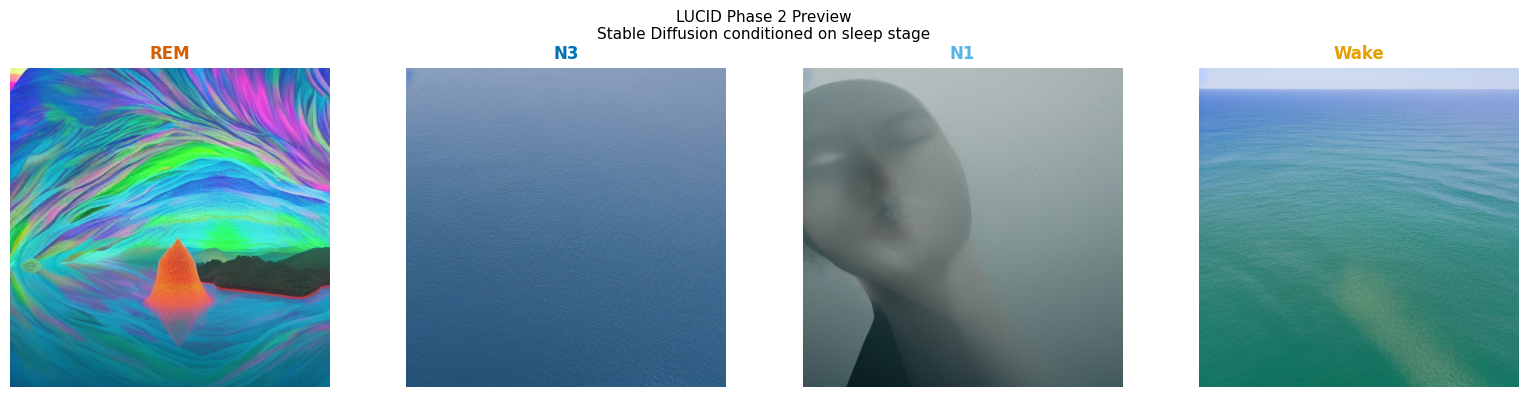


 Gallery saved to C:\Users\Hp\.vscode\Journey to the BEST\Week 10\generated_images\sleep_stage_gallery.png


In [6]:
import copy
import uuid
import json
import websocket
from PIL import Image
import io
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ── Load your workflow ─────────────────────────────────────
WORKFLOW_PATH = (r"C:\Users\Hp\.vscode\Journey to the BEST"
                 r"\Week 10\comfyui_api\workflow_api.json")

with open(WORKFLOW_PATH) as f:
    base_workflow = json.load(f)

print(" Workflow loaded")
print(f"   Nodes: {list(base_workflow.keys())}")


# ── Generate with different EEG-inspired prompts ──────────
# Map sleep stages to descriptive prompts
# In Phase 2, these prompts come from EEG features
# For now: manually map stage → visual prompt

STAGE_PROMPTS = {
    'REM': (
        "vivid dreamscape, surreal floating islands, "
        "bioluminescent colors, theta wave patterns, "
        "neural activity visualization, REM sleep, "
        "dreamlike quality, soft glow, otherworldly"
    ),
    'N3': (
        "deep dark ocean, slow delta waves, "
        "peaceful darkness, deep sleep visualization, "
        "slow brain waves, navy blue, cosmic void, "
        "minimalist, serene"
    ),
    'N1': (
        "hypnagogic imagery, fragmented shapes, "
        "half-awake visions, alpha to theta transition, "
        "light sleep onset, misty, ethereal, fading"
    ),
    'Wake': (
        "sharp clear landscape, beta wave energy, "
        "bright daylight, alert mind, crisp details, "
        "vibrant colors, active neural patterns"
    ),
}

NEGATIVE = ("blurry, distorted, low quality, "
             "deformed, text, watermark, ugly")


def generate_for_stage(stage_name: str,
                        workflow: dict,
                        seed: int = None) -> Image.Image:
    """
    Generate an image for a given sleep stage.
    This simulates Phase 2 where EEG features
    drive the conditioning instead of text.
    """
    wf = copy.deepcopy(workflow)

    # Update positive prompt
    wf["8"]["inputs"]["text"] = STAGE_PROMPTS[stage_name]

    # Update negative prompt
    wf["3"]["inputs"]["text"] = NEGATIVE

    # Set seed (or randomise)
    if seed is not None:
        wf["4"]["inputs"]["seed"] = seed
    else:
        wf["4"]["inputs"]["seed"] = torch.randint(
            0, 2**32, (1,)).item()

    # Faster generation
    wf["4"]["inputs"]["steps"] = 15
    wf["4"]["inputs"]["cfg"]   = 7.5

    # Connecting to ComfyUI
    client_id = str(uuid.uuid4())
    ws_url    = (f"ws://127.0.0.1:8188/ws"
                 f"?clientId={client_id}")

    ws = websocket.WebSocket()
    ws.connect(ws_url)

    try:
        prompt_id = get_images(ws, wf, client_id)
        images    = get_output_images(prompt_id)
        if images:
            return Image.open(io.BytesIO(images[0]))
        return None
    finally:
        ws.close()


# ── Generate one image per sleep stage ────────────────────
print("Generating sleep stage visualisations...\n")
print("(Each takes ~30 seconds on CPU, less on GPU)\n")

generated = {}
for stage in ['REM', 'N3', 'N1', 'Wake']:
    print(f"Generating {stage}...", end=' ', flush=True)
    try:
        img = generate_for_stage(stage, base_workflow,
                                  seed=42)
        generated[stage] = img
        print("✅")
    except Exception as e:
        print(f"❌ {e}")

# ── Displaying results ────────────────────────────────────────
if generated:
    fig, axes = plt.subplots(
        1, len(generated),
        figsize=(4 * len(generated), 4)
    )
    if len(generated) == 1:
        axes = [axes]

    stage_colors = {
        'REM': '#D55E00', 'N3': '#0072B2',
        'N1': '#56B4E9', 'Wake': '#E69F00'
    }

    for ax, (stage, img) in zip(axes, generated.items()):
        ax.imshow(img)
        ax.set_title(
            stage,
            fontsize=12, fontweight='bold',
            color=stage_colors.get(stage, 'black')
        )
        ax.axis('off')

    plt.suptitle(
        'LUCID Phase 2 Preview\n'
        'Stable Diffusion conditioned on sleep stage',
        fontsize=11
    )
    plt.tight_layout()

    save_path = (r"C:\Users\Hp\.vscode\Journey to the BEST"
                 r"\Week 10\generated_images"
                 r"\sleep_stage_gallery.png")
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    plt.show()
    print(f"\n Gallery saved to {save_path}")

In [7]:
# ── This is the actual Phase 2 architecture ───────────────
# Replacing text prompts with CNN-LSTM features

class EEGToPrompt:
    """
    Converts CNN-LSTM sleep stage prediction
    to a Stable Diffusion prompt.

    Phase 2 upgrade: replace this lookup table
    with a trained EEGAlignmentMLP that outputs
    CLIP embeddings directly — no text needed.
    """

    STAGE_MAP = {
        0: 'Wake',
        1: 'N1',
        2: 'N2',
        3: 'N3',
        4: 'REM'
    }

    # Extend prompts with N2
    PROMPTS = {
        **STAGE_PROMPTS,
        'N2': (
            "sleep spindles, K-complexes, "
            "intermediate sleep, sigma waves, "
            "neutral dreamscape, soft textures, "
            "light purple, transitional state"
        )
    }

    def __init__(self, cnn_lstm_model=None):
        self.model = cnn_lstm_model

    def predict_stage(self, eeg_epoch: torch.Tensor):
        """
        Given raw EEG epoch, return predicted stage.
        eeg_epoch: (3000,) tensor
        """
        if self.model is None:
            # Simulate for demo
            return torch.randint(0, 5, (1,)).item()

        self.model.eval()
        with torch.no_grad():
            logits = self.model(
                eeg_epoch.unsqueeze(0)
            )
            return logits.argmax(1).item()

    def get_prompt(self, stage_idx: int) -> str:
        stage_name = self.STAGE_MAP[stage_idx]
        return self.PROMPTS.get(stage_name, '')

    def generate_from_eeg(self,
                           eeg_epoch: torch.Tensor,
                           workflow: dict) -> Image.Image:
        """
        Full pipeline: EEG → stage → prompt → image.
        This is LUCID Phase 2 (text-conditioned version).
        Phase 2.5: replace get_prompt() with EEG embedding.
        """
        stage_idx  = self.predict_stage(eeg_epoch)
        stage_name = self.STAGE_MAP[stage_idx]
        prompt     = self.get_prompt(stage_idx)

        print(f"EEG → Stage: {stage_name}")
        print(f"Prompt: {prompt[:60]}...")

        return generate_for_stage(
            stage_name, workflow
        ), stage_name


# ── Testing with simulated EEG ────────────────────────────────
converter = EEGToPrompt(cnn_lstm_model=None)

# Simulate what our CNN-LSTM would output
# during actual sleep monitoring
simulated_epochs = {
    'Simulated REM epoch':   4,
    'Simulated N3 epoch':    3,
    'Simulated Wake epoch':  0,
}

print("=== EEG → Image Pipeline Simulation ===\n")
for epoch_name, stage_idx in simulated_epochs.items():
    prompt = converter.get_prompt(stage_idx)
    stage  = converter.STAGE_MAP[stage_idx]
    print(f"{epoch_name}:")
    print(f"  Stage:  {stage}")
    print(f"  Prompt: {prompt[:70]}...")
    print()

print("In Phase 2 (with Muse S):")
print("  Real EEG → your CNN-LSTM → stage prediction")
print("  Stage → EEGAlignmentMLP → CLIP embedding")
print("  CLIP embedding → ComfyUI KSampler")
print("  → Real-time dream imagery generation")

=== EEG → Image Pipeline Simulation ===

Simulated REM epoch:
  Stage:  REM
  Prompt: vivid dreamscape, surreal floating islands, bioluminescent colors, the...

Simulated N3 epoch:
  Stage:  N3
  Prompt: deep dark ocean, slow delta waves, peaceful darkness, deep sleep visua...

Simulated Wake epoch:
  Stage:  Wake
  Prompt: sharp clear landscape, beta wave energy, bright daylight, alert mind, ...

In Phase 2 (with Muse S):
  Real EEG → your CNN-LSTM → stage prediction
  Stage → EEGAlignmentMLP → CLIP embedding
  CLIP embedding → ComfyUI KSampler
  → Real-time dream imagery generation


In [8]:
# ── Phase 2 upgrade path: IP-Adapter ──────────────────────
# IP-Adapter lets us condition SD on an IMAGE embedding
# instead of text. The embedding has the same structure
# as what our EEGAlignmentMLP outputs.
#
# ComfyUI has IP-Adapter support built in.
# This is how we go from text-prompt Phase 2
# to true EEG-embedding Phase 2.

ip_adapter_workflow = {
    **base_workflow,

    # Adding IP-Adapter loader
    "10": {
        "inputs": {
            "ipadapter": "ip-adapter_sd15.bin",
            "clip_vision": "CLIP-ViT-H-14-laion2B.safetensors"
        },
        "class_type": "IPAdapterModelLoader",
        "_meta": {"title": "IP-Adapter Loader"}
    },

    # Adding EEG embedding injection
    "11": {
        "inputs": {
            "model":      ["2", 0],
            "ipadapter":  ["10", 0],
            "image":      ["12", 0],  # our EEG feature image
            "weight":     0.7,         # balance text vs EEG
            "start_at":   0.0,
            "end_at":     1.0,
        },
        "class_type": "IPAdapter",
        "_meta": {"title": "EEG IP-Adapter"}
    },
}

print("=== IP-Adapter Upgrade Path ===\n")
print("Current pipeline (text-conditioned):")
print("  EEG → stage → text prompt → CLIP → U-Net")
print()
print("Phase 2 pipeline (embedding-conditioned):")
print("  EEG → CNN-LSTM → EEGAlignmentMLP → embedding")
print("  embedding → IP-Adapter → U-Net (no text needed)")
print()
print("IP-Adapter downloads needed:")
print("  ip-adapter_sd15.bin            (~290MB)")
print("  CLIP-ViT-H-14-laion2B.bin      (~3.9GB)")
print()
print("Then in ComfyUI:")
print("  Add IPAdapterModelLoader node")
print("  Connect your EEG embedding as the 'image' input")
print("  The model generates images matching EEG features")
print()
print("This is the technical bridge between")
print("Phase 1 (sleep staging) and Phase 2 (imagery).")

=== IP-Adapter Upgrade Path ===

Current pipeline (text-conditioned):
  EEG → stage → text prompt → CLIP → U-Net

Phase 2 pipeline (embedding-conditioned):
  EEG → CNN-LSTM → EEGAlignmentMLP → embedding
  embedding → IP-Adapter → U-Net (no text needed)

IP-Adapter downloads needed:
  ip-adapter_sd15.bin            (~290MB)
  CLIP-ViT-H-14-laion2B.bin      (~3.9GB)

Then in ComfyUI:
  Add IPAdapterModelLoader node
  Connect your EEG embedding as the 'image' input
  The model generates images matching EEG features

This is the technical bridge between
Phase 1 (sleep staging) and Phase 2 (imagery).
